# Simulación de lo que queda del Mundial 2026

Sin API. Uso Elo + forma histórica + Poisson.

La localía solo se aplica a **USA, Canada y Mexico**, aunque aparezcan como visitantes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

N_SIMS = 30000
AVG_WC_GOALS = 2.52
ELO_INIT = 1500
K = 30

HOST_NATIONS = {'United States', 'USA', 'Canada', 'Mexico'}
HOST_FACTOR = 1.08
INJURY_FACTOR = {}

NAME_MAP = {
    'USA': 'United States',
    'United States of America': 'United States',
    'Korea Republic': 'South Korea',
    'Türkiye': 'Turkey',
    'Côte d’Ivoire': 'Ivory Coast',
    'Côte d\'Ivoire': 'Ivory Coast',
    'Czechia': 'Czech Republic',
    'Curaçao': 'Curacao',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'Bosnia and Herzegowina': 'Bosnia and Herzegovina',
    'Congo DR': 'DR Congo',
    'Democratic Republic of Congo': 'DR Congo',
}

ELO_FALLBACK = {
    'Argentina': 2140, 'France': 2090, 'Spain': 2070, 'Brazil': 2040,
    'England': 2030, 'Portugal': 2020, 'Belgium': 1960, 'Colombia': 1940,
    'Croatia': 1920, 'Netherlands': 1980, 'Germany': 1970, 'Morocco': 1840,
    'Mexico': 1850, 'United States': 1830, 'Switzerland': 1820, 'Austria': 1810,
    'Canada': 1760, 'Paraguay': 1780, 'Norway': 1770, 'Algeria': 1760,
    'Egypt': 1750, 'Ghana': 1720, 'Australia': 1710, 'Cape Verde': 1660,
    'South Africa': 1650, 'Japan': 1800, 'Ivory Coast': 1730, 'Sweden': 1760,
    'Ecuador': 1800, 'DR Congo': 1650, 'Senegal': 1800,
    'Bosnia and Herzegovina': 1680
}

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f7',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 10,
    'text.color': '#1a1a1a',
    'axes.labelcolor': '#1a1a1a',
    'axes.titlecolor': '#1a1a1a',
    'xtick.color': '#1a1a1a',
    'ytick.color': '#1a1a1a',
    'legend.labelcolor': '#1a1a1a'
})

Cargo el histórico para sacar Elo y forma reciente. Si falla la descarga, el notebook usa ratings base para no romperse.

In [2]:
HIST_URL = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'

try:
    df = pd.read_csv(HIST_URL, parse_dates=['date'])
    df['home_team'] = df['home_team'].map(lambda x: NAME_MAP.get(x, x))
    df['away_team'] = df['away_team'].map(lambda x: NAME_MAP.get(x, x))
    df = df.dropna(subset=['home_score', 'away_score'])
    print('Histórico cargado:', df.shape)
except Exception as e:
    print('No se pudo cargar el histórico, uso fallback')
    print(e)
    df = pd.DataFrame(columns=['date', 'home_team', 'away_team', 'home_score', 'away_score'])

Histórico cargado: (49487, 9)


In [3]:
def expected_score(r_a, r_b):
    return 1 / (1 + 10 ** ((r_b - r_a) / 400))


def update_elo(r_a, r_b, score_a, k=K):
    exp_a = expected_score(r_a, r_b)
    return r_a + k * (score_a - exp_a)


def build_elo(df):
    ratings = {}

    for _, row in df.sort_values('date').iterrows():
        h = row['home_team']
        a = row['away_team']
        hs = row['home_score']
        away_s = row['away_score']

        rh = ratings.get(h, ELO_INIT)
        ra = ratings.get(a, ELO_INIT)

        if hs > away_s:
            sh, sa = 1, 0
        elif hs < away_s:
            sh, sa = 0, 1
        else:
            sh, sa = 0.5, 0.5

        ratings[h] = update_elo(rh, ra, sh)
        ratings[a] = update_elo(ra, rh, sa)

    for team, val in ELO_FALLBACK.items():
        ratings.setdefault(team, val)

    return ratings


elo = build_elo(df)

pd.Series(elo).sort_values(ascending=False).head(15)

Argentina      2063.343729
Spain          2043.158777
France         2015.288407
Brazil         1970.046747
England        1956.138290
Portugal       1950.835512
Colombia       1943.979886
Netherlands    1930.679900
Germany        1929.642233
Morocco        1921.007741
Mexico         1917.200149
Japan          1897.818206
Italy          1893.358721
Belgium        1892.248900
Croatia        1886.686247
dtype: float64

In [4]:
def recent_form(team, n=10, decay=0.85):
    if df.empty:
        return {'gf': 1.3, 'ga': 1.1}

    tmp = df[(df['home_team'] == team) | (df['away_team'] == team)].sort_values('date').tail(n)

    if tmp.empty:
        return {'gf': 1.3, 'ga': 1.1}

    gf = []
    ga = []

    for _, row in tmp.iterrows():
        if row['home_team'] == team:
            gf.append(row['home_score'])
            ga.append(row['away_score'])
        else:
            gf.append(row['away_score'])
            ga.append(row['home_score'])

    w = np.array([decay ** (len(gf) - 1 - i) for i in range(len(gf))])
    w = w / w.sum()

    return {
        'gf': float(np.average(gf, weights=w)),
        'ga': float(np.average(ga, weights=w))
    }


def team_base_stats(team):
    f = recent_form(team)
    return {
        'gf_avg': max(f['gf'], 0.4),
        'ga_avg': max(f['ga'], 0.4)
    }


def host_factor(team):
    return HOST_FACTOR if team in HOST_NATIONS else 1.0


def get_lambda(attacker_stats, defender_stats, attacker_form, defender_form,
               elo_att, elo_def, home_factor=1.0, injury_factor=1.0):

    gf_api = attacker_stats.get('gf_avg', AVG_WC_GOALS)
    ga_api = defender_stats.get('ga_avg', AVG_WC_GOALS)
    lam_api = (gf_api / AVG_WC_GOALS) * (ga_api / AVG_WC_GOALS) * AVG_WC_GOALS

    gf_hist = attacker_form['gf']
    ga_hist = defender_form['ga']
    lam_hist = (gf_hist / AVG_WC_GOALS) * (ga_hist / AVG_WC_GOALS) * AVG_WC_GOALS

    elo_ratio = 10 ** ((elo_att - elo_def) / 800)
    lam_elo = AVG_WC_GOALS * elo_ratio

    lam = 0.50 * lam_api + 0.35 * lam_hist + 0.15 * lam_elo
    lam *= home_factor
    lam *= injury_factor

    return round(max(lam, 0.2), 3)

In [5]:
def simular_partido(home, away, ronda):
    s_h = team_base_stats(home)
    s_a = team_base_stats(away)
    f_h = recent_form(home)
    f_a = recent_form(away)

    elo_h = elo.get(home, ELO_FALLBACK.get(home, ELO_INIT))
    elo_a = elo.get(away, ELO_FALLBACK.get(away, ELO_INIT))

    lam_h = get_lambda(
        s_h, s_a, f_h, f_a, elo_h, elo_a,
        home_factor=host_factor(home),
        injury_factor=INJURY_FACTOR.get(home, 1.0)
    )

    lam_a = get_lambda(
        s_a, s_h, f_a, f_h, elo_a, elo_h,
        home_factor=host_factor(away),
        injury_factor=INJURY_FACTOR.get(away, 1.0)
    )

    gh = np.random.poisson(lam_h, N_SIMS)
    ga = np.random.poisson(lam_a, N_SIMS)

    p_h = np.mean(gh > ga)
    p_d = np.mean(gh == ga)
    p_a = np.mean(gh < ga)

    p_pen_h = 0.51 if elo_h >= elo_a else 0.49
    p_pen_a = 1 - p_pen_h

    extra = p_d * 0.50

    p_h_total = p_h + extra * p_pen_h + extra * (lam_h / (lam_h + lam_a))
    p_a_total = p_a + extra * p_pen_a + extra * (lam_a / (lam_h + lam_a))

    ganador = home if p_h_total >= p_a_total else away
    perdedor = away if ganador == home else home

    marcador = pd.Series([f'{h}-{a}' for h, a in zip(gh, ga)]).value_counts(normalize=True).idxmax()

    return {
        'Ronda': ronda,
        'Local': home,
        'Visitante': away,
        'Ganador': ganador,
        'Perdedor': perdedor,
        'P local 90': p_h,
        'P empate 90': p_d,
        'P visita 90': p_a,
        'P pasa local': p_h_total,
        'P pasa visita': p_a_total,
        'Prob ganador': max(p_h_total, p_a_total),
        'Marcador probable': marcador,
        'xG local': lam_h,
        'xG visita': lam_a,
        'Elo local': elo_h,
        'Elo visita': elo_a,
    }

Estos ya los dejo fijos porque ya estaban jugados. Lo demás se simula.

In [6]:
oficiales_r32 = {
    'Canada': 'Canada',
    'Morocco': 'Morocco',
    'Paraguay': 'Paraguay',
    'France': 'France',
    'Brazil': 'Brazil',
    'Norway': 'Norway',
    'Mexico': 'Mexico',
    'England': 'England',
    'Belgium': 'Belgium',
    'United States': 'United States',
}

pendientes_r32 = [
    ('Spain', 'Austria'),
    ('Portugal', 'Croatia'),
    ('Switzerland', 'Algeria'),
    ('Australia', 'Egypt'),
    ('Argentina', 'Cape Verde'),
    ('Colombia', 'Ghana')
]

In [7]:
sim = []

for h, a in pendientes_r32:
    sim.append(simular_partido(h, a, 'R32'))

w_spain_austria = sim[-6]['Ganador']
w_portugal_croatia = sim[-5]['Ganador']
w_switzerland_algeria = sim[-4]['Ganador']
w_australia_egypt = sim[-3]['Ganador']
w_argentina_capeverde = sim[-2]['Ganador']
w_colombia_ghana = sim[-1]['Ganador']

# Octavos
r = simular_partido('Canada', 'Morocco', 'Octavos'); sim.append(r); w_o1 = r['Ganador']
r = simular_partido('Paraguay', 'France', 'Octavos'); sim.append(r); w_o2 = r['Ganador']
r = simular_partido('Brazil', 'Norway', 'Octavos'); sim.append(r); w_o3 = r['Ganador']
r = simular_partido('Mexico', 'England', 'Octavos'); sim.append(r); w_o4 = r['Ganador']
r = simular_partido(w_portugal_croatia, w_spain_austria, 'Octavos'); sim.append(r); w_o5 = r['Ganador']
r = simular_partido('United States', 'Belgium', 'Octavos'); sim.append(r); w_o6 = r['Ganador']
r = simular_partido(w_argentina_capeverde, w_australia_egypt, 'Octavos'); sim.append(r); w_o7 = r['Ganador']
r = simular_partido(w_switzerland_algeria, w_colombia_ghana, 'Octavos'); sim.append(r); w_o8 = r['Ganador']

# Cuartos
r = simular_partido(w_o1, w_o2, 'Cuartos'); sim.append(r); w_q1 = r['Ganador']
r = simular_partido(w_o5, w_o6, 'Cuartos'); sim.append(r); w_q2 = r['Ganador']
r = simular_partido(w_o3, w_o4, 'Cuartos'); sim.append(r); w_q3 = r['Ganador']
r = simular_partido(w_o7, w_o8, 'Cuartos'); sim.append(r); w_q4 = r['Ganador']

# Semis
r = simular_partido(w_q1, w_q2, 'Semifinal'); sim.append(r); finalista_1 = r['Ganador']; perdedor_sf1 = r['Perdedor']
r = simular_partido(w_q3, w_q4, 'Semifinal'); sim.append(r); finalista_2 = r['Ganador']; perdedor_sf2 = r['Perdedor']

# Tercer lugar y final
r = simular_partido(perdedor_sf1, perdedor_sf2, 'Tercer lugar'); sim.append(r); tercer_lugar = r['Ganador']
r = simular_partido(finalista_1, finalista_2, 'Final'); sim.append(r); campeon = r['Ganador']; subcampeon = r['Perdedor']

df_mundial = pd.DataFrame(sim)

df_mundial['Prob ganador'] = df_mundial['Prob ganador'].map(lambda x: f'{x:.1%}')
df_mundial['P local 90'] = df_mundial['P local 90'].map(lambda x: f'{x:.1%}')
df_mundial['P empate 90'] = df_mundial['P empate 90'].map(lambda x: f'{x:.1%}')
df_mundial['P visita 90'] = df_mundial['P visita 90'].map(lambda x: f'{x:.1%}')
df_mundial['P pasa local'] = df_mundial['P pasa local'].map(lambda x: f'{x:.1%}')
df_mundial['P pasa visita'] = df_mundial['P pasa visita'].map(lambda x: f'{x:.1%}')

df_mundial[['Ronda', 'Local', 'Visitante', 'Ganador', 'Prob ganador', 'Marcador probable', 'xG local', 'xG visita']]

,Ronda,Local,Visitante,Ganador,Prob ganador,Marcador probable,xG local,xG visita
0,R32,Spain,Austria,Spain,78.5%,1-0,1.489,0.488
1,R32,Portugal,Croatia,Portugal,74.7%,1-0,1.558,0.659
2,R32,Switzerland,Algeria,Switzerland,56.0%,1-1,1.333,1.119
3,R32,Australia,Egypt,Egypt,54.5%,0-0,0.674,0.792
4,R32,Argentina,Cape Verde,Argentina,94.0%,2-0,2.335,0.228
5,R32,Colombia,Ghana,Colombia,88.2%,1-0,1.727,0.283
6,Octavos,Canada,Morocco,Morocco,55.8%,0-0,0.824,0.994
7,Octavos,Paraguay,France,France,82.7%,0-1,0.483,1.763
8,Octavos,Brazil,Norway,Brazil,73.7%,1-0,1.847,0.871
9,Octavos,Mexico,England,Mexico,57.3%,0-0,0.795,0.602


In [8]:
print('=' * 45)
print('SIMULACIÓN FINAL')
print('=' * 45)
print('Campeón:     ', campeon)
print('Subcampeón:  ', subcampeon)
print('Tercer lugar:', tercer_lugar)
print('=' * 45)

SIMULACIÓN FINAL
Campeón:      Argentina
Subcampeón:   Spain
Tercer lugar: Mexico


Con este resultado de México, como mexicano dias antes del partido de Octavos de final, no me queda mas que preguntarme, ¿Y si, si?

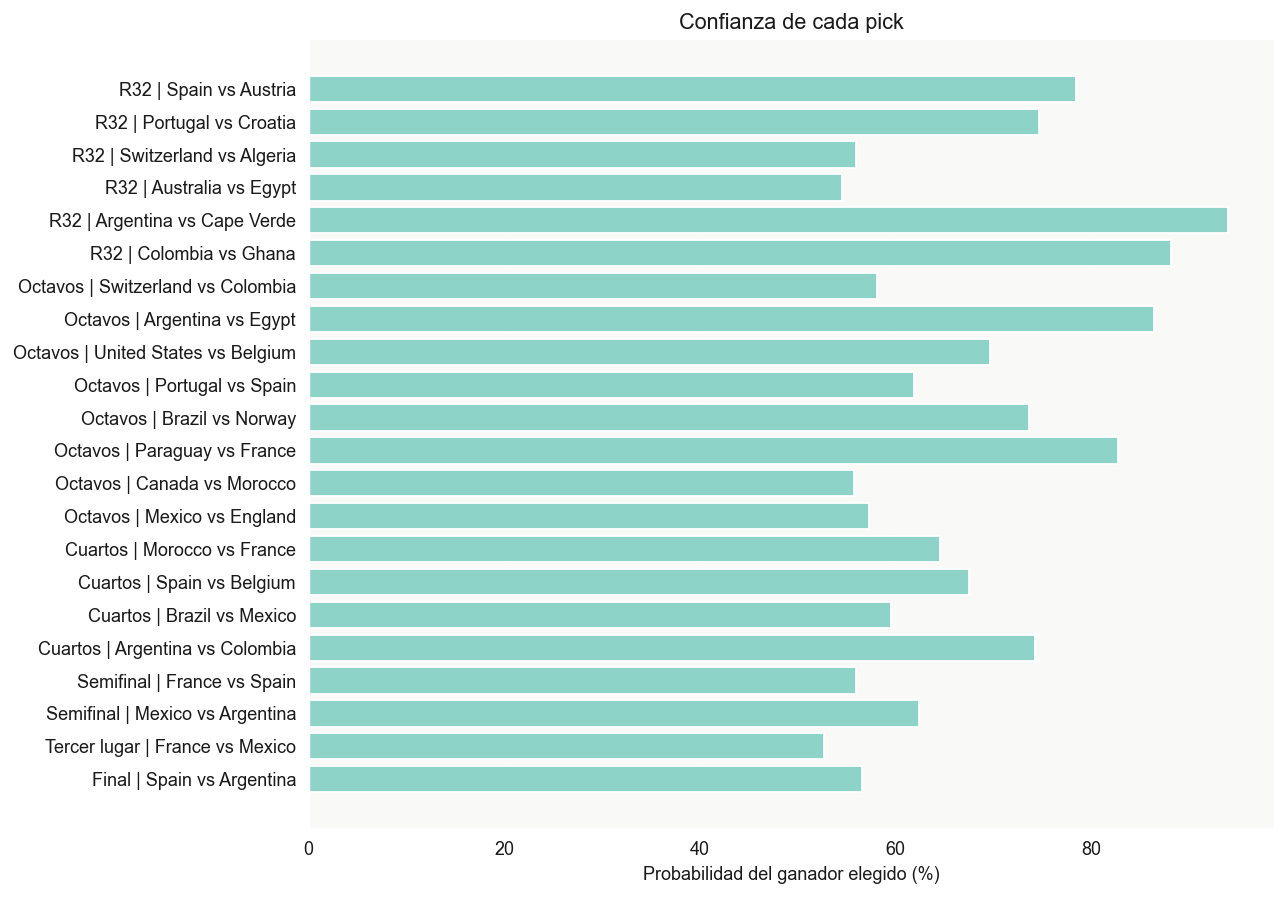

In [9]:
orden = ['R32', 'Octavos', 'Cuartos', 'Semifinal', 'Tercer lugar', 'Final']
plot_df = df_mundial.copy()
plot_df['Ronda'] = pd.Categorical(plot_df['Ronda'], categories=orden, ordered=True)
plot_df = plot_df.sort_values('Ronda')

plt.figure(figsize=(10, 7))
plt.barh(
    plot_df['Ronda'].astype(str) + ' | ' + plot_df['Local'] + ' vs ' + plot_df['Visitante'],
    plot_df['Prob ganador'].str.replace('%', '').astype(float)
)
plt.xlabel('Probabilidad del ganador elegido (%)')
plt.title('Confianza de cada pick')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Si quiero cambiar una baja importante, solo edito algo así y vuelvo a correr desde la simulación:

```python
INJURY_FACTOR['France'] = 0.95
```

Para localía no toco nada: el factor solo entra si el equipo es USA, Canada o Mexico.